# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [1]:
%pip install transformers torch tqdm datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
# import os

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification

import configuration
from src import setup, data_utils, hf_utils
from src.models import bert

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_frac = data_utils.DATA_FRACTION

# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = setup.setup_device_with_seeds()

batch_size = 32
learning_rate = 1e-5
num_epochs = 10
patience = 3  # early stopping, if validation loss does not improve for this many epochs

bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
# Optimizer
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

base_configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

GPU: NVIDIA H100 80GB HBM3
Memory allocated: 0.0 GB
Memory cached: 0.0 GB
Using device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7642.28it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [3]:
def run_experiment(weather_ratio, out_topic_ratio):
    
    df_train, df_val, df_test = data_utils.load_BERT_sets(
        weather_ratio=weather_ratio, out_topic_ratio=out_topic_ratio
    )
    
    # # ====
    # # Comment out this cell to use the full dataset. This is just for quick testing.
    # train_size = 1000
    # val_size = int(train_size * len(df_val) / len(df_train))
    # test_size = int(train_size * len(df_test) / len(df_train))

    # df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
    # df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
    # df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)
    # # ----

    ds_train, ds_val, ds_test = hf_utils.create_datasets(df_train, df_val, df_test)

    # Calculate the maximum length of the tokenized tweets in the training set to set the max_length parameter for BERT
    hf_utils.max_length_dist(df_train, "tweet_text", tokenizer)
    
    ration_folder = data_utils.get_experiment_ratios_path(weather_ratio, out_topic_ratio)

    # Tokenize the datasets and save the tokenized versions.
    token_path = Path(
        f"../tokens/BERT/{ration_folder}"
    )
    train_tokenized, val_tokenized, test_tokenized = hf_utils.load_or_tokenize(
        ds_train,
        ds_val,
        ds_test,
        tokenizer,
        token_path,
        force_retokenize=True,
        format_dataset=bert.format_dataset,
    )
    
    imbalance_strategy = bert.detect_imbalance_strategy(df_train["informative"])
    print(f"Detected imbalance strategy: {imbalance_strategy}")
    
    configs = {**base_configs, **imbalance_strategy}
    configs['save_path'] = f"../models/BERT/{ration_folder}"

    # Fine-tune BERT
    model, train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history = bert.finetune(
        train_tokenized, val_tokenized, configs
    )

    # Visualize training history
    hf_utils.plot_fine_tune_history(
        train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history
    )

    predictions = bert.predict(model, test_tokenized, device)
    bert.report_metrics(test_tokenized, predictions)
    hf_utils.group_report_metrics(
        df_test, predictions, group_by="subset", labels="informative"
    )

Processing dataset with weather_ratio=1 and out_topic_ratio=0.729871...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (586 > 512). Running this sequence through the model will result in indexing errors


90th percentile: 42.0
95th percentile: 47.0
99th percentile: 56.0
Absolute Maximum length: 7685
Tokenizing datasets...


Saving the dataset (1/1 shards): 100%|██████████| 47624/47624 [00:00<00:00, 693750.62 examples/s]


Dataset Imbalance Ratio (IR): 14.98
Status: Extreme Imbalance. Using Focal Loss.
Detected imbalance strategy: {'strategy': 'focal_loss', 'minority_class_id': True, 'class_weights': tensor([0.5334, 7.9922]), 'use_sampler': False, 'use_focal_loss': True, 'imbalance_ratio': 14.984350744703168}
Starting BertForSequenceClassification fine-tuning...
Active Strategy: FOCAL_LOSS
--------------------------------------------------


...

Validating Epoch 5/10: 100%|██████████| 1489/1489 [00:18<00:00, 80.26it/s]


Epoch 5/10 | Train Loss: 0.0088 | Val Loss: 0.0474 | Val Macro F1: 0.9180 | Val Recall: 0.9671 | Val Precision: 0.8797


Validating Epoch 6/10: 100%|██████████| 1489/1489 [00:18<00:00, 81.95it/s]


Epoch 6/10 | Train Loss: 0.0069 | Val Loss: 0.0439 | Val Macro F1: 0.9191 | Val Recall: 0.9605 | Val Precision: 0.8856
Early stopping triggered at epoch 6. Best Val Recall: 0.9703
Loaded best model with Val Recall: 0.9703


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]


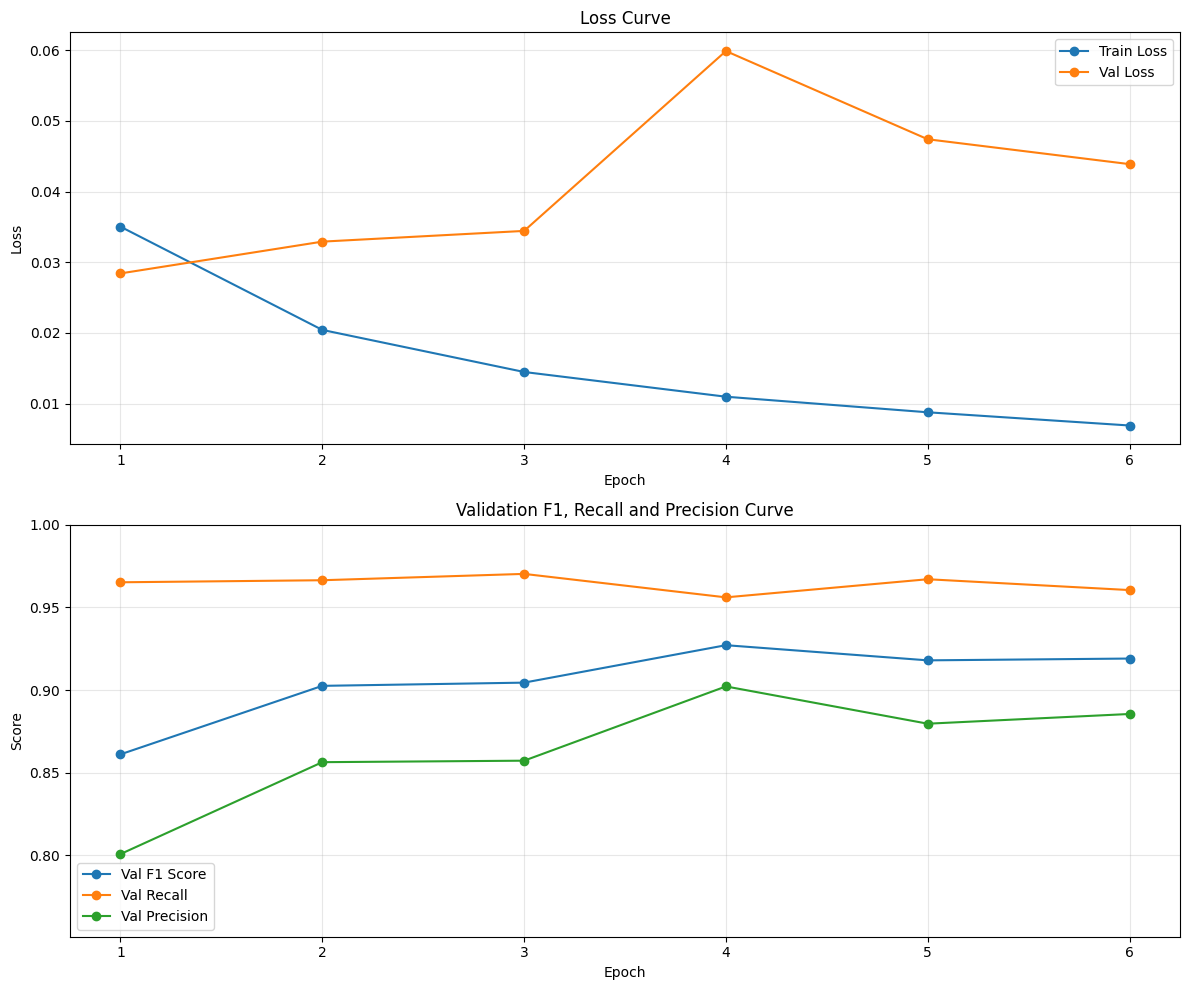

Predicting:: 100%|██████████| 2977/2977 [00:24<00:00, 120.79it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9978    0.9723    0.9849     44644
        True     0.7000    0.9678    0.8124      2980

    accuracy                         0.9720     47624
   macro avg     0.8489    0.9700    0.8986     47624
weighted avg     0.9792    0.9720    0.9741     47624

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9564    0.7065    0.8127      2978
        True     0.7674    0.9678    0.8560      2980

    accuracy                         0.8372      5958
   macro avg     0.8619    0.8371    0.8344      5958
weighted avg     0.8619    0.8372    0.8344      5958

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9918    0.9959     40373
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

90th percentile: 42.0
95th percentile: 46.0
99th percentile: 55.0
Absolute Maximum length: 1722
Tokenizing datasets...


Saving the dataset (1/1 shards): 100%|██████████| 62506/62506 [00:00<00:00, 575358.85 examples/s]


...

Validating Epoch 3/10: 100%|██████████| 1954/1954 [00:23<00:00, 81.63it/s]


Epoch 3/10 | Train Loss: 0.0075 | Val Loss: 0.0405 | Val Macro F1: 0.9414 | Val Recall: 0.9720 | Val Precision: 0.9149


Validating Epoch 4/10: 100%|██████████| 1954/1954 [00:24<00:00, 81.12it/s]


Epoch 4/10 | Train Loss: 0.0063 | Val Loss: 0.0311 | Val Macro F1: 0.9422 | Val Recall: 0.9746 | Val Precision: 0.9143
Early stopping triggered at epoch 4. Best Val Recall: 0.9857
Loaded best model with Val Recall: 0.9857


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]


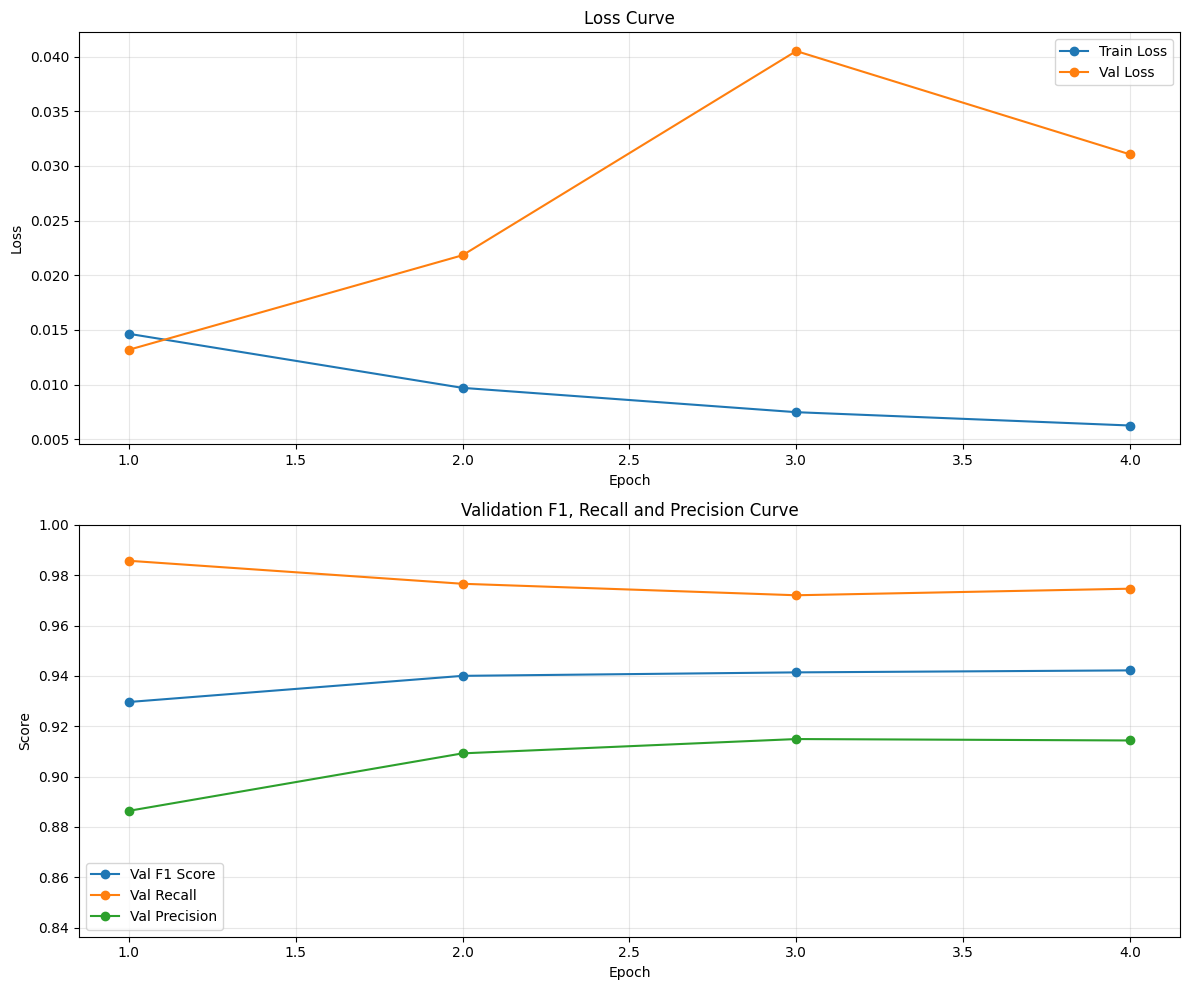

Predicting:: 100%|██████████| 3907/3907 [00:33<00:00, 115.73it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9992    0.9862    0.9926     59526
        True     0.7810    0.9836    0.8706      2980

    accuracy                         0.9861     62506
   macro avg     0.8901    0.9849    0.9316     62506
weighted avg     0.9888    0.9861    0.9868     62506

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9797    0.7956    0.8781      2975
        True     0.8282    0.9836    0.8992      2980

    accuracy                         0.8897      5955
   macro avg     0.9040    0.8896    0.8887      5955
weighted avg     0.9039    0.8897    0.8887      5955

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982     55264
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

In [4]:
for weather_ratio, out_topic_ratio in data_utils.BERT_EXPERIMENT_RATIOS:
    print(
        f"Processing dataset with weather_ratio={weather_ratio} and out_topic_ratio={out_topic_ratio}..."
    )
    run_experiment(weather_ratio, out_topic_ratio)